In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
sns.set_style()

In [6]:
df = pd.read_csv('german_credit_data.csv')

In [5]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [6]:
df['Age'].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [7]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [8]:
df.shape[0]

1000

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [10]:
df.describe(include='all')

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


In [11]:
df['Job'].unique()

array([2, 1, 3, 0])

In [12]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [15]:
df.drop(columns='Unnamed: 0', inplace=True)

In [16]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

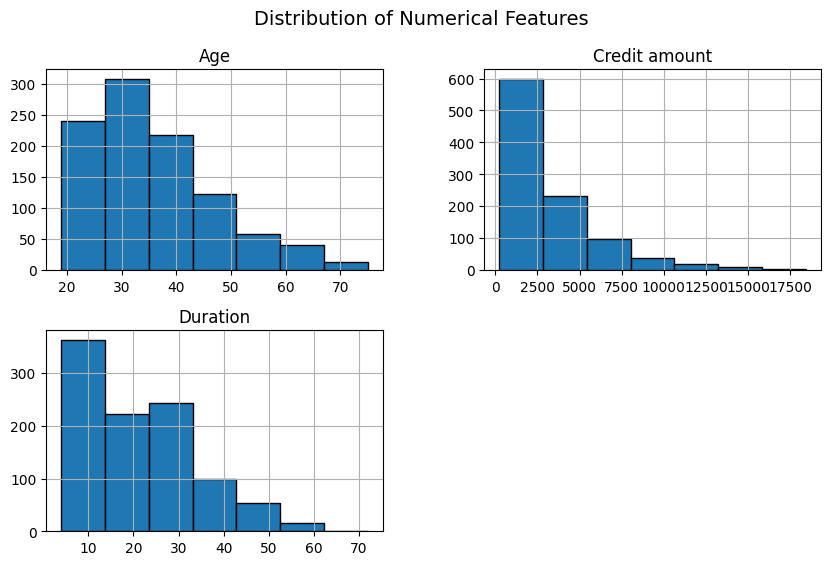

In [17]:
df[['Age', 'Credit amount', 'Duration']].hist(bins=7, edgecolor='black', figsize=(10, 6))
plt.suptitle('Distribution of Numerical Features', fontsize=14)
plt.show()

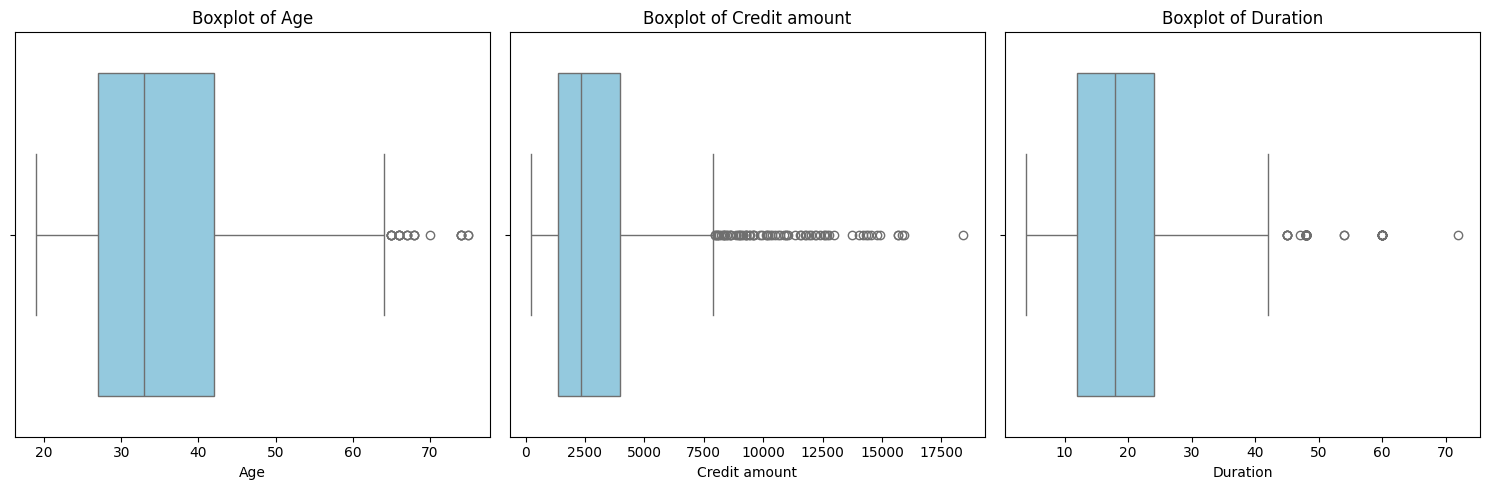

In [18]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(['Age', 'Credit amount', 'Duration']):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [19]:
df.query('Duration>=60')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,63,male,2,own,little,little,6836,60,business,bad
134,21,female,2,own,moderate,NaN,10144,60,radio/TV,good
255,27,male,1,own,NaN,moderate,7418,60,radio/TV,good
332,24,female,3,own,moderate,moderate,7408,60,car,bad
373,63,male,3,free,NaN,NaN,13756,60,car,good
374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
616,27,male,3,free,NaN,moderate,9157,60,radio/TV,good
637,21,male,2,own,little,NaN,15653,60,radio/TV,good
672,42,male,3,own,little,NaN,10366,60,car,good
677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [20]:
categorical_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

/var/folders/wf/6r33qs395z37m0g2gzqqq1s00000gn/T/ipykernel_31895/1288794817.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='Set2', order=df[col].value_counts().index)
/var/folders/wf/6r33qs395z37m0g2gzqqq1s00000gn/T/ipykernel_31895/1288794817.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='Set2', order=df[col].value_counts().index)
/var/folders/wf/6r33qs395z37m0g2gzqqq1s00000gn/T/ipykernel_31895/1288794817.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], palette='Set2', orde

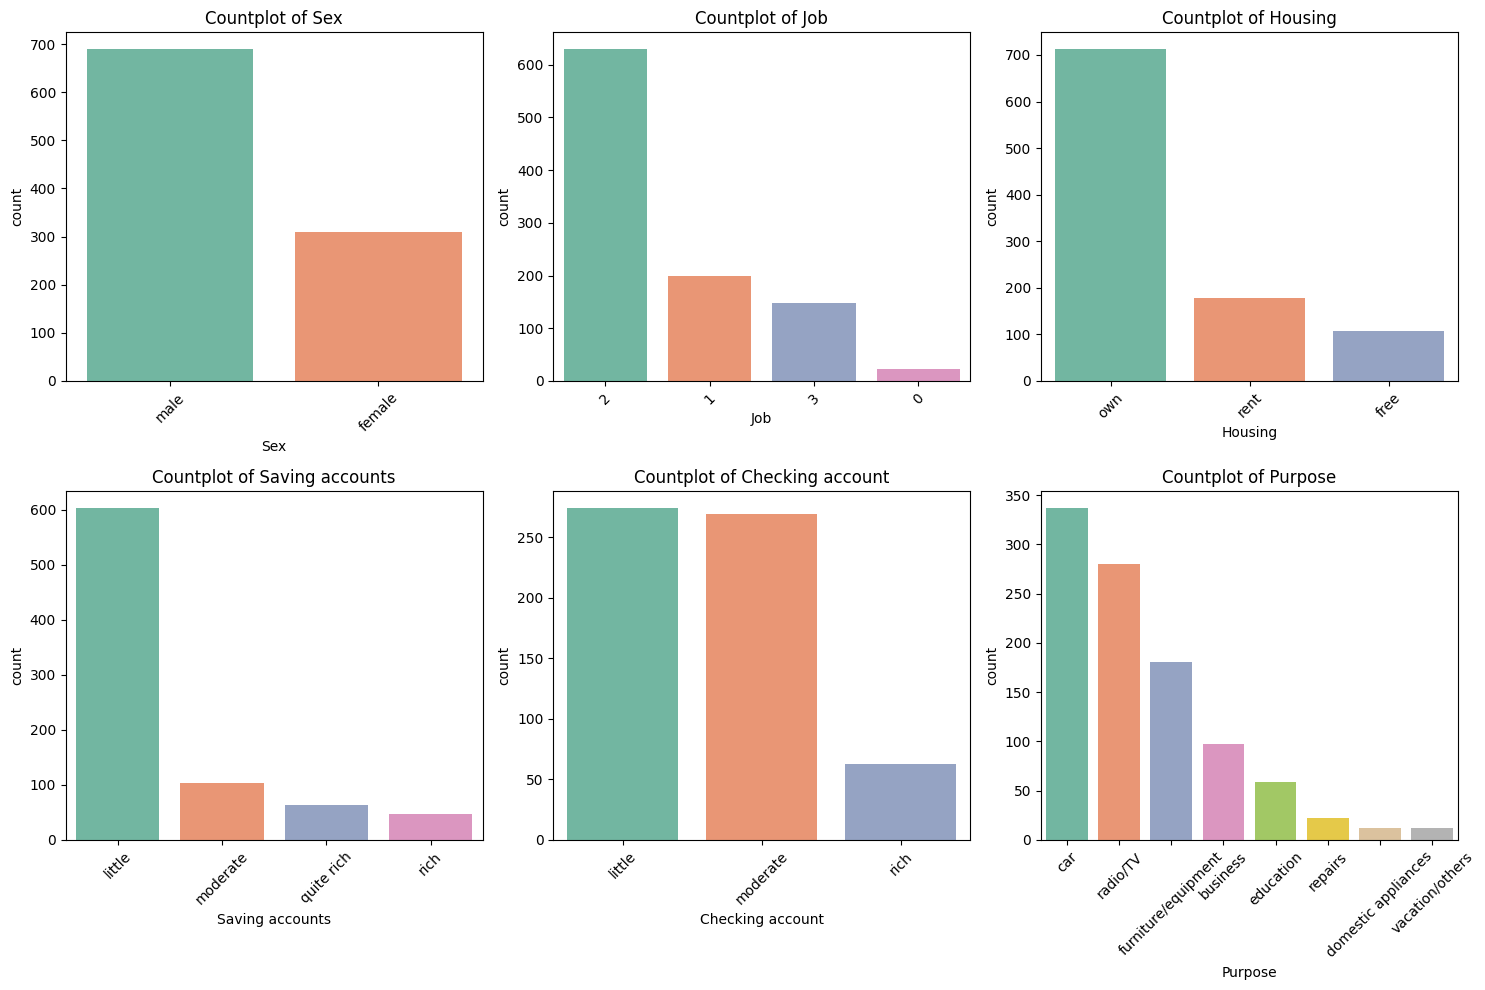

In [21]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=df[col], palette='Set2', order=df[col].value_counts().index)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
corr = df[['Age', 'Credit amount', 'Duration']].corr()

In [23]:
corr

,Age,Credit amount,Duration
Age,1.000000,0.032716,-0.036136
Credit amount,0.032716,1.000000,0.624984
Duration,-0.036136,0.624984,1.000000


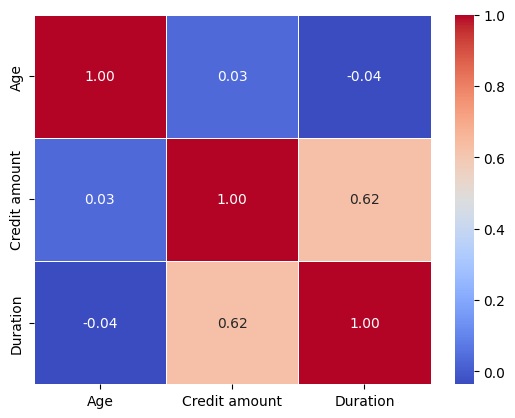

In [24]:
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.show()

In [25]:
df.groupby('Job')['Credit amount'].mean()

Job
0    2745.136364
1    2358.520000
2    3070.965079
3    5435.493243
Name: Credit amount, dtype: float64

In [26]:
df.groupby('Sex')['Credit amount'].mean()

Sex
female    2877.774194
male      3448.040580
Name: Credit amount, dtype: float64

In [27]:
pd.pivot_table(df, values='Credit amount', index='Housing', columns='Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4931.800000,5834.181818,NaN,4387.266667,4100.181818,2417.333333,2750.666667,7227.250
own,3800.592105,3329.949772,1546.5,2198.647059,3107.459016,2540.493392,2866.000000,8700.375
rent,5614.125000,3487.968254,1255.5,2931.000000,2727.354167,2199.763158,1522.000000,NaN


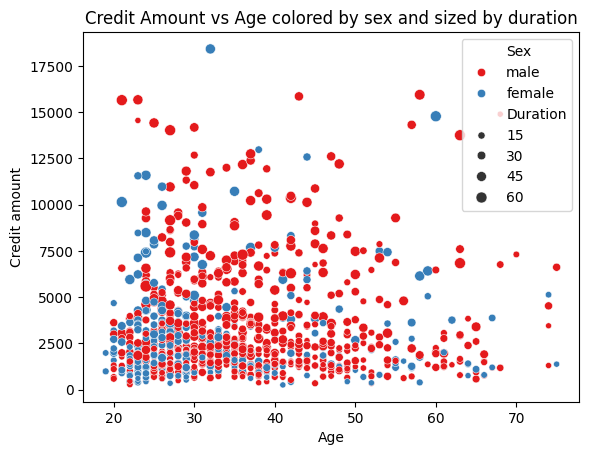

In [28]:
sns.scatterplot(data=df, x='Age', y='Credit amount', hue='Sex', size='Duration', palette='Set1')
plt.title('Credit Amount vs Age colored by sex and sized by duration')
plt.show()

/var/folders/wf/6r33qs395z37m0g2gzqqq1s00000gn/T/ipykernel_31895/3837150244.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Saving accounts', y='Credit amount', data=df, palette='Set3')


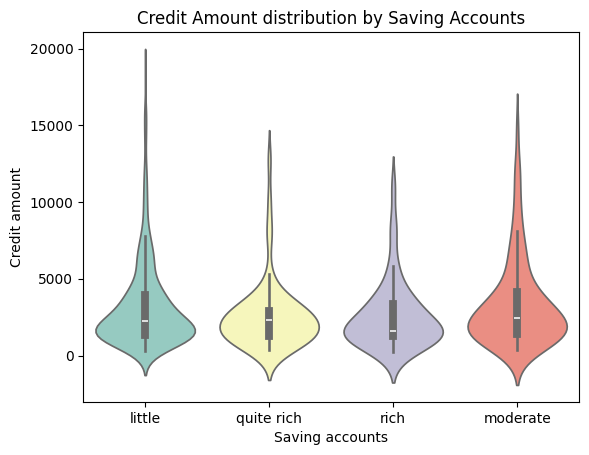

In [ ]:
sns.violinplot(x='Saving accounts', y='Credit amount', data=df, palette='Set3')
plt.title('Credit Amount distribution by Saving Accounts')
plt.show()

In [7]:
df["Risk"].value_counts(normalize=True)*100

Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64

/var/folders/wf/6r33qs395z37m0g2gzqqq1s00000gn/T/ipykernel_2628/3799243549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Risk", y=col, data=df, palette="Set2")
/var/folders/wf/6r33qs395z37m0g2gzqqq1s00000gn/T/ipykernel_2628/3799243549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Risk", y=col, data=df, palette="Set2")
/var/folders/wf/6r33qs395z37m0g2gzqqq1s00000gn/T/ipykernel_2628/3799243549.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Risk", y=col, data=df, palette="Set2")


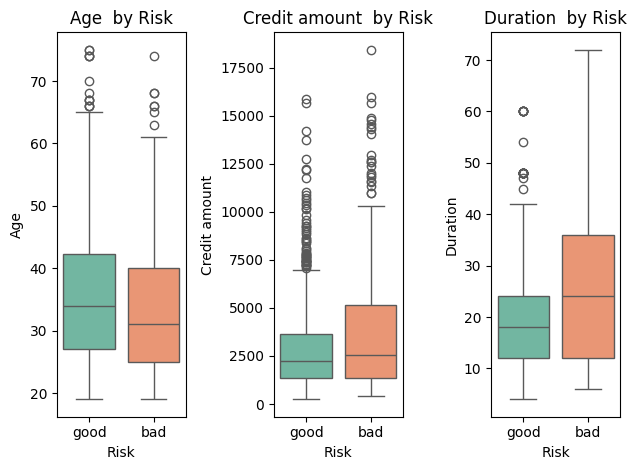

In [8]:
for i, col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x="Risk", y=col, data=df, palette="Set2")
    plt.title(f"{col}  by Risk")
plt.tight_layout()
plt.show()

In [9]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,33.963333,3938.126667,24.860000
good,36.224286,2985.457143,19.207143


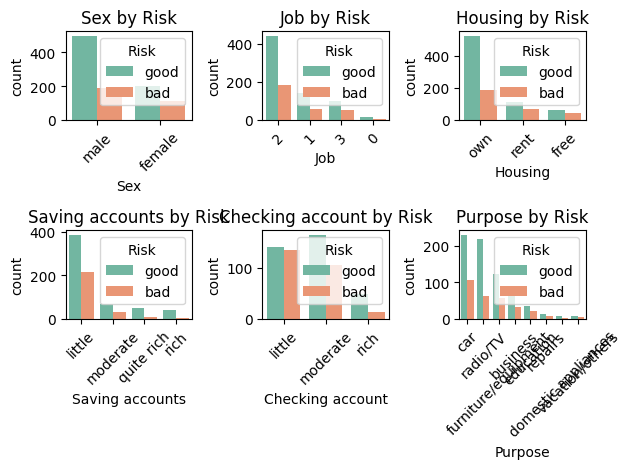

In [11]:
categorical_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)
    sns.countplot(x=df[col], hue=df["Risk"], palette="Set2", order=df[col].value_counts().index)
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='str')

In [13]:
features=["Age","Sex","Job","Housing","Saving accounts","Checking account","Credit amount","Duration","Purpose"]

In [14]:
target="Risk"

In [15]:
df_model=df[features+[target]].copy()

In [16]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [17]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [18]:
cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")

/var/folders/wf/6r33qs395z37m0g2gzqqq1s00000gn/T/ipykernel_2628/714141096.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_model.select_dtypes(include="object").columns.drop("Risk")


In [19]:
le_dict={}

In [20]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='str')

In [21]:
for col in cat_cols:
    le=LabelEncoder()
    df_model[col]=le.fit_transform(df_model[col])
    le_dict[col]=le
    joblib.dump(le, f"{col}_label_encoder.pkl")

In [22]:
le_target=LabelEncoder()

In [23]:
target


'Risk'

In [24]:
df_model[target]=le_target.fit_transform(df_model[target])

In [25]:
df_model[target].value_counts()

Risk
1    700
0    300
Name: count, dtype: int64

In [26]:
joblib.dump(le_target,"target_encoder.pkl")

['target_encoder.pkl']

In [27]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,4,0,1169,6,5,1
1,22,0,2,1,0,1,5951,48,5,0
2,49,1,1,1,0,3,2096,12,3,1
3,45,1,2,0,0,0,7882,42,4,1
4,53,1,2,0,0,0,4870,24,1,0


In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X=df_model.drop(columns=target)
Y=df_model[target]

In [30]:
X_train , X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=1)

In [31]:
X_train.shape

(800, 9)

In [32]:
X_test.shape


(200, 9)

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier  # Requires OpenMP runtime
from sklearn.metrics import accuracy_score 
from sklearn.model_selection import GridSearchCV

In [34]:
def train_model(model,param_grid,X_train,Y_train,X_test,Y_test):
    grid=GridSearchCV(model,param_grid,cv=5,scoring="accuracy",n_jobs=-1)
    grid.fit(X_train,Y_train)
    best_model=grid.best_estimator_
    Y_pred=best_model.predict(X_test)
    acc=accuracy_score(Y_test,Y_pred)
    return best_model,acc,grid.best_params_
    

In [35]:
dt=DecisionTreeClassifier(random_state=1,class_weight="balanced")
dt_param_grid={
    "max_depth":[3,5,7,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

best_dt,acc_dt,params_dt = train_model(dt,dt_param_grid,X_train,Y_train,X_test,Y_test)

In [36]:
print("Decision Tree Accuracy",acc_dt)

NameError: name 'acc_dt' is not defined